# HD-corrected VS GLM · full / eye-midpoint-only / XY-only / HD-only geometry

In [234]:
import json
import sys
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.spatial.transform import Rotation

sys.path.append(str(Path.cwd().parent))
from Utils.tuning_curve_utils import get_exposure_timestamps

session_ID: int = 10
session_dir = Path(f"/mnt/senzailab/Kai/#Recording/m19/260827/260827_{session_ID}")

data_dir = session_dir / "data"
kilosort_dir = session_dir / f"kilosort/ProbeA/kilosort_{session_ID}"
calibration_path = session_dir / "260821.calib"
output_dir = data_dir / "glm"
unit_id = 261
bin_size = 0.02
angle_bin_size = 12
pre_onset_lag = -0.1
max_lag = 0.25
train_fraction = 0.8
regularizer_strength = 0.001
random_seed = 0
headplate_name = "hp4"
camera_input_channel = 1
camera_ttl_threshold = 14000


## 1. 读 mat file

In [235]:
session_metadata = json.loads((data_dir / "session_info.json").read_text())
session_info = session_metadata["session_info"]
session_name = Path(session_info["base_path"]).name
trials = loadmat(
    session_dir / f"{session_name}.mat", simplify_cells=True,
)["trials"]

spike_samples = np.load(kilosort_dir / "spike_times.npy")
spike_clusters = np.load(kilosort_dir / "spike_clusters.npy")
unit_info = np.genfromtxt(
    kilosort_dir / "cluster_KSLabel.tsv",
    delimiter="\t", names=True, dtype=None, encoding="utf-8",
)
unit_label = unit_info["KSLabel"][unit_info["cluster_id"] == unit_id][0]
unit_mask = spike_clusters == unit_id

on_list_times = np.load(data_dir / "on_list_times.npy")


# Real HD is frame-indexed; the raw camera TTL supplies ADC-clock times.
hd_path = data_dir / "processed/head_direction.json"
hd_payload = json.loads(hd_path.read_text())[headplate_name]
hd_frames_all = np.asarray(hd_payload["frames"], dtype=int)
frame_head_direction_all = np.asarray(
    hd_payload["head_direction_deg"], dtype=float,
)
frame_times_relative, adc_time_origin, ttl_qc = get_exposure_timestamps(
    session_info, camera_input_channel, camera_ttl_threshold,
    camera_ttl_active_high=True,
)
camera_frame_times = frame_times_relative + adc_time_origin
# Session 5 Motive recording continued after Open Ephys stopped.
# Frame zero matches the first TTL; only unmatched trailing Motive frames are dropped.
hd_trailing_frame_count = len(frame_head_direction_all) - len(camera_frame_times)
hd_frames = hd_frames_all[:len(camera_frame_times)]
frame_head_direction = frame_head_direction_all[:len(camera_frame_times)] % 360

calibration = json.loads(calibration_path.read_text())
motive = pd.read_csv(
    session_dir / f"{session_name}.csv",
    header=[2, 3, 6, 7], skip_blank_lines=False,
)
frame_hp4_position = motive["Rigid Body"][headplate_name]["Position"][
    ["X", "Y", "Z"]
].to_numpy()[:len(camera_frame_times)]
frame_hp4_rotation = motive["Rigid Body"][headplate_name]["Rotation"][
    ["X", "Y", "Z"]
].to_numpy()[:len(camera_frame_times)]
frame_eye_offset = Rotation.from_euler(
    "XYZ", frame_hp4_rotation, degrees=True,
).apply(np.asarray(calibration["hp_to_eye_center"]))
frame_eye_position = frame_hp4_position + frame_eye_offset
screen_zero_deg = calibration["screen_center"]
screen_center_xy = np.asarray(calibration["screen_bottom_center"][:2])
screen_radius = calibration["screen_diamter"] / 2


## 4. 用 calibration 把 hp4 转到 eye midpoint，再计算 VS bearing

In [236]:
vs_info = {
    "start": on_list_times[:-1],
    "end": on_list_times[1:],
    "position": np.array([trial["Square_PositionX"] for trial in trials]),
    "luminance": np.array([trial["Square_Luminance"] for trial in trials]),
}
bin_count = int((on_list_times[-1] - on_list_times[0]) / bin_size)
time_edges = on_list_times[0] + np.arange(bin_count + 1) * bin_size
time = time_edges[:-1] + bin_size / 2
trial_index = np.searchsorted(on_list_times, time, side="right") - 1
screen_position = vs_info["position"][trial_index]
# Unwrap before interpolation so 360/0 crossings remain continuous.
hd_unwrapped = np.unwrap(np.radians(frame_head_direction))
head_direction = np.degrees(
    np.interp(time, camera_frame_times, hd_unwrapped)
) % 360
hp4_x = np.interp(time, camera_frame_times, frame_hp4_position[:, 0])
hp4_y = np.interp(time, camera_frame_times, frame_hp4_position[:, 1])
eye_offset_x = np.interp(time, camera_frame_times, frame_eye_offset[:, 0])
eye_offset_y = np.interp(time, camera_frame_times, frame_eye_offset[:, 1])
eye_x = hp4_x + eye_offset_x
eye_y = hp4_y + eye_offset_y
screen_angle = np.radians(screen_position + screen_zero_deg)
bar_x = screen_center_xy[0] + screen_radius * np.cos(screen_angle)
bar_y = screen_center_xy[1] + screen_radius * np.sin(screen_angle)
def corrected_vs_position(
    raw_position, bar_x, bar_y, observer_x, observer_y, hd, hd_sign=1,
):
    bar_bearing = np.degrees(np.arctan2(
        bar_y - observer_y, bar_x - observer_x,
    ))
    center_bearing = raw_position + screen_zero_deg
    bearing_delta = (bar_bearing - center_bearing + 180) % 360 - 180
    prior_rf_position = (raw_position + 180 + hd_sign * hd) % 360
    return (prior_rf_position + bearing_delta) % 360

# All four coordinates are HD-corrected.
vs_position = corrected_vs_position(
    screen_position, bar_x, bar_y, eye_x, eye_y, head_direction,
)
vs_position_minus_hd = corrected_vs_position(
    screen_position, bar_x, bar_y, eye_x, eye_y, head_direction, hd_sign=-1,
)
vs_position_eye_only = corrected_vs_position(
    screen_position, bar_x, bar_y,
    screen_center_xy[0] + eye_offset_x,
    screen_center_xy[1] + eye_offset_y, head_direction,
)
vs_position_xy_no_eye = corrected_vs_position(
    screen_position, bar_x, bar_y, hp4_x, hp4_y, head_direction,
)
vs_position_hd_only = (screen_position + 180 + head_direction) % 360
white_trial = vs_info["luminance"] == 1
white = white_trial[trial_index]

# 每一个 white trial 的起点都是 VS onset；不是只找 white block 的 0 -> 1。
onset_bin = np.searchsorted(
    time_edges, vs_info["start"][white_trial], side="right",
) - 1
onset_head_direction = np.degrees(np.interp(
    vs_info["start"][white_trial], camera_frame_times, hd_unwrapped,
)) % 360
onset_hp4_x = np.interp(
    vs_info["start"][white_trial], camera_frame_times, frame_hp4_position[:, 0],
)
onset_hp4_y = np.interp(
    vs_info["start"][white_trial], camera_frame_times, frame_hp4_position[:, 1],
)
onset_eye_offset_x = np.interp(
    vs_info["start"][white_trial], camera_frame_times, frame_eye_offset[:, 0],
)
onset_eye_offset_y = np.interp(
    vs_info["start"][white_trial], camera_frame_times, frame_eye_offset[:, 1],
)
onset_eye_x = onset_hp4_x + onset_eye_offset_x
onset_eye_y = onset_hp4_y + onset_eye_offset_y
onset_screen_angle = np.radians(
    vs_info["position"][white_trial] + screen_zero_deg
)
onset_bar_x = screen_center_xy[0] + screen_radius * np.cos(onset_screen_angle)
onset_bar_y = screen_center_xy[1] + screen_radius * np.sin(onset_screen_angle)
onset_position = corrected_vs_position(
    vs_info["position"][white_trial], onset_bar_x, onset_bar_y,
    onset_eye_x, onset_eye_y, onset_head_direction,
)
onset_position_minus_hd = corrected_vs_position(
    vs_info["position"][white_trial], onset_bar_x, onset_bar_y,
    onset_eye_x, onset_eye_y, onset_head_direction, hd_sign=-1,
)
onset_position_eye_only = corrected_vs_position(
    vs_info["position"][white_trial], onset_bar_x, onset_bar_y,
    screen_center_xy[0] + onset_eye_offset_x,
    screen_center_xy[1] + onset_eye_offset_y, onset_head_direction,
)
onset_position_xy_no_eye = corrected_vs_position(
    vs_info["position"][white_trial], onset_bar_x, onset_bar_y,
    onset_hp4_x, onset_hp4_y, onset_head_direction,
)
onset_position_hd_only = (
    vs_info["position"][white_trial] + 180 + onset_head_direction
) % 360
onset = np.zeros(len(time), dtype=int)
onset[onset_bin] = 1


## 5. 建立 unit spike time 和每个 bin 的 spike count

In [237]:
# 已按 Kilosort 行顺序映射到 ADC clock；不要直接 samples / sample_rate。
adc_spike_times = np.load(data_dir / "probeA/adc_spike_time.npy")
unit_spike_times = adc_spike_times[unit_mask]
unit_spike_samples = spike_samples[unit_mask]
spike_counts = np.histogram(unit_spike_times, time_edges)[0]


## 6. NeMoS 基础：binary 角度 basis + binary FIR lag basis

In [238]:
# jax.config.update("jax_enable_x64", True)
angle_count = 360 // angle_bin_size
angle_edges = np.arange(angle_count + 1) * angle_bin_size
angle_centers = (angle_edges[:-1] + angle_edges[1:]) / 2
angle_basis = np.eye(angle_count)
lag_steps = np.arange(round(max_lag / bin_size) + 1)
lags = np.concatenate([[pre_onset_lag], lag_steps * bin_size])
lag_basis = np.eye(len(lags))

model = nmo.glm.GLM(
    observation_model=nmo.observation_models.PoissonObservations(),
    regularizer="Ridge",
    regularizer_strength=regularizer_strength,
    solver_name="LBFGS",
    solver_kwargs={"maxiter": 2000},
)


## 7. 建立 eye-position-corrected VS onset × FIR + additive HD design

In [239]:
stimulus_onset = np.zeros((len(time), angle_count))
onset_angle = (onset_position // angle_bin_size).astype(int)
stimulus_onset[onset_bin, onset_angle] = 1
stimulus_onset_minus_hd = np.zeros((len(time), angle_count))
onset_angle_minus_hd = (onset_position_minus_hd // angle_bin_size).astype(int)
stimulus_onset_minus_hd[onset_bin, onset_angle_minus_hd] = 1
stimulus_onset_eye_only = np.zeros((len(time), angle_count))
onset_angle_eye_only = (onset_position_eye_only // angle_bin_size).astype(int)
stimulus_onset_eye_only[onset_bin, onset_angle_eye_only] = 1
stimulus_onset_xy_no_eye = np.zeros((len(time), angle_count))
onset_angle_xy_no_eye = (onset_position_xy_no_eye // angle_bin_size).astype(int)
stimulus_onset_xy_no_eye[onset_bin, onset_angle_xy_no_eye] = 1
stimulus_onset_hd_only = np.zeros((len(time), angle_count))
onset_angle_hd_only = (onset_position_hd_only // angle_bin_size).astype(int)
stimulus_onset_hd_only[onset_bin, onset_angle_hd_only] = 1
stimulus_dynamic = np.zeros((len(time), angle_count))
dynamic_angle = (vs_position // angle_bin_size).astype(int)
stimulus_dynamic[np.flatnonzero(white), dynamic_angle[white]] = 1

pre_onset_bin = np.searchsorted(
    time_edges, vs_info["start"][white_trial] + pre_onset_lag, side="right",
) - 1
pre_onset_valid = pre_onset_bin >= 0
def make_pre_onset_stimulus(onset_angles):
    pre_onset_stimulus = np.zeros((len(time), angle_count))
    pre_onset_stimulus[
        pre_onset_bin[pre_onset_valid], onset_angles[pre_onset_valid]
    ] = 1
    return pre_onset_stimulus

stimulus_pre_onset = make_pre_onset_stimulus(onset_angle)
stimulus_pre_onset_minus_hd = make_pre_onset_stimulus(onset_angle_minus_hd)
stimulus_pre_onset_eye_only = make_pre_onset_stimulus(onset_angle_eye_only)
stimulus_pre_onset_xy_no_eye = make_pre_onset_stimulus(onset_angle_xy_no_eye)
stimulus_pre_onset_hd_only = make_pre_onset_stimulus(onset_angle_hd_only)
dynamic_source_bin = np.flatnonzero(white)
dynamic_pre_onset_bin = np.searchsorted(
    time_edges, time[dynamic_source_bin] + pre_onset_lag, side="right",
) - 1
dynamic_pre_onset_valid = dynamic_pre_onset_bin >= 0
stimulus_dynamic_pre_onset = np.zeros((len(time), angle_count))
stimulus_dynamic_pre_onset[
    dynamic_pre_onset_bin[dynamic_pre_onset_valid],
    dynamic_angle[dynamic_source_bin[dynamic_pre_onset_valid]],
] = 1

sample_index = np.arange(lag_steps[-1], len(time))
# -100 ms 按绝对 onset time 构造，不 round 成 30 ms grid 上的 -90 ms。
# 其余列按非负 lag 排列，每个 lag 内为 angle_count 个角度。
vs_design = np.column_stack(
    [stimulus_pre_onset[sample_index]]
    + [stimulus_onset[sample_index - lag] for lag in lag_steps]
)
vs_design_minus_hd = np.column_stack(
    [stimulus_pre_onset_minus_hd[sample_index]]
    + [stimulus_onset_minus_hd[sample_index - lag] for lag in lag_steps]
)
vs_design_dynamic = np.column_stack(
    [stimulus_dynamic_pre_onset[sample_index]]
    + [stimulus_dynamic[sample_index - lag] for lag in lag_steps]
)
vs_design_eye_only = np.column_stack(
    [stimulus_pre_onset_eye_only[sample_index]]
    + [stimulus_onset_eye_only[sample_index - lag] for lag in lag_steps]
)
vs_design_xy_no_eye = np.column_stack(
    [stimulus_pre_onset_xy_no_eye[sample_index]]
    + [stimulus_onset_xy_no_eye[sample_index - lag] for lag in lag_steps]
)
vs_design_hd_only = np.column_stack(
    [stimulus_pre_onset_hd_only[sample_index]]
    + [stimulus_onset_hd_only[sample_index - lag] for lag in lag_steps]
)
time = time[sample_index]
trial_index = trial_index[sample_index]
screen_position = screen_position[sample_index]
head_direction = head_direction[sample_index]
hp4_x = hp4_x[sample_index]
hp4_y = hp4_y[sample_index]
eye_x = eye_x[sample_index]
eye_y = eye_y[sample_index]
vs_position = vs_position[sample_index]
vs_position_minus_hd = vs_position_minus_hd[sample_index]
vs_position_eye_only = vs_position_eye_only[sample_index]
vs_position_xy_no_eye = vs_position_xy_no_eye[sample_index]
vs_position_hd_only = vs_position_hd_only[sample_index]
onset = onset[sample_index]
white = white[sample_index]
spike_counts = spike_counts[sample_index]

split_time = on_list_times[int(len(trials) * train_fraction)]
train = time < split_time + pre_onset_lag
test = time >= split_time + max_lag

# XY/eye affect only the VS angle; they are not separate GLM covariates.
# Keep the same additive HD term in all four geometry models.
hd_radians = np.radians(head_direction)
hd_features_raw = np.column_stack([
    np.cos(hd_radians), np.sin(hd_radians),
])
hd_feature_mean = hd_features_raw[train].mean(axis=0)
hd_feature_scale = hd_features_raw[train].std(axis=0)
hd_features = (hd_features_raw - hd_feature_mean) / hd_feature_scale
vs_feature_count = vs_design.shape[1]
design = np.column_stack([vs_design, hd_features])
design.shape


(59977, 422)

## 8. Fit eye-position-corrected VS + HD GLM -> predict

In [240]:
model.fit(design[train], spike_counts[train])
predicted_counts = np.asarray(model.predict(design))
firing_rate = predicted_counts / bin_size
generated_spike_counts = np.random.default_rng(random_seed).poisson(predicted_counts)


In [241]:
predicted_counts


array([0.7270943 , 0.75674975, 0.73126495, ..., 0.63669705, 0.64344114,
       0.6474581 ], shape=(59977,), dtype=float32)

## 9. GLM result save

In [242]:
output_dir.mkdir(exist_ok=True)
model.save_params(output_dir / f"{unit_id}_model.npz")
np.savetxt(
    output_dir / "vs_info.csv", np.column_stack(list(vs_info.values())),
    delimiter=",", header="start,end,position,luminance", comments="", fmt="%.18g",
)
np.savetxt(
    output_dir / "head_direction_aligned.csv",
    np.column_stack([hd_frames, camera_frame_times, frame_head_direction]),
    delimiter=",", header="frame,camera_time_adc,head_direction_deg",
    comments="", fmt="%.18g",
)
np.savetxt(
    output_dir / f"{unit_id}_spikes.csv",
    np.column_stack([unit_spike_samples, unit_spike_times]),
    delimiter=",", header="spike_samples,spike_times", comments="", fmt=["%d", "%.18g"],
)
result = np.column_stack([
    time, trial_index, screen_position, head_direction, hp4_x, hp4_y, eye_x, eye_y,
    vs_position, vs_position_eye_only, vs_position_xy_no_eye,
    vs_position_hd_only, onset, white,
    spike_counts, predicted_counts,
    firing_rate, generated_spike_counts, train, test,
])
np.savetxt(
    output_dir / f"{unit_id}.csv", result, delimiter=",", comments="", fmt="%.18g",
    header="time,trial_index,raw_vs_position,head_direction,hp4_x,hp4_y,eye_x,eye_y,"
           "vs_bearing_xy_eye,vs_bearing_eye_only,vs_bearing_xy_no_eye,"
           "vs_bearing_hd_only,"
           "onset,white,spike_counts,predicted_counts,"
           "firing_rate,generated_spike_counts,train,test",
)
design_labels = [
    f"vs_{angle}_lag_{lag}"
    for lag in np.rint(lags * 1000).astype(int) for angle in angle_edges[:-1]
] + ["hd_cos_z", "hd_sin_z"]
np.savetxt(
    output_dir / f"{unit_id}_design.csv", design, delimiter=",", fmt="%.18g",
    header=",".join(design_labels), comments="",
)
# 输入和输出重建使用相同的 binary basis；拟合出的系数不是 0/1。
all_coefficients = np.asarray(model.coef_)
coefficients = all_coefficients[:vs_feature_count].reshape(
    len(lags), angle_count,
).T
rf = angle_basis @ coefficients @ lag_basis.T
np.savetxt(
    output_dir / f"{unit_id}_rf.csv",
    np.column_stack([np.repeat(angle_centers, len(lags)),
                     np.tile(lags, angle_count), rf.ravel()]),
    delimiter=",", header="vs_bearing_xy_eye,lag,coefficient", comments="", fmt="%.18g",
)

hd_parameters = {
    "source": str(hd_path),
    "calibration": str(calibration_path),
    "feature_names": design_labels[-2:],
    "training_mean": hd_feature_mean.tolist(),
    "training_scale": hd_feature_scale.tolist(),
    "coefficients": all_coefficients[vs_feature_count:].tolist(),
}
(output_dir / f"{unit_id}_hd.json").write_text(
    json.dumps(hd_parameters, indent=2) + "\n"
)


467

## 10. Plot GLM RF：VS angle × lag

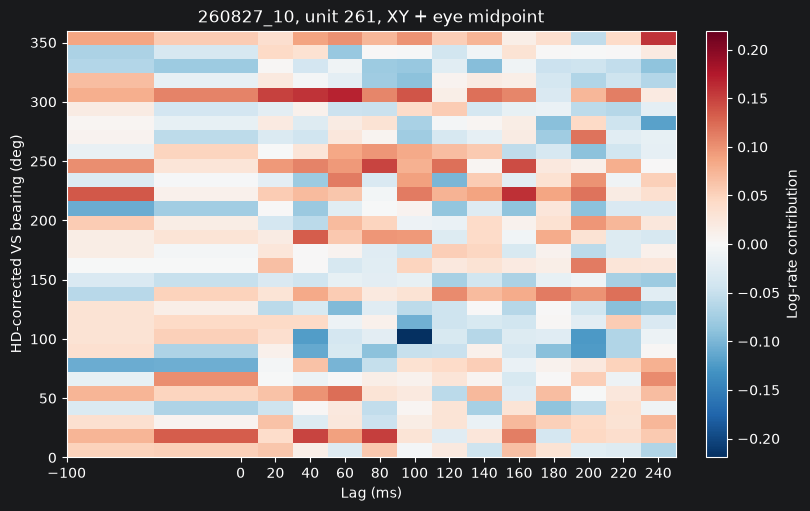

In [243]:
fig, axis = plt.subplots(figsize=(8, 5), layout="constrained")
limit = np.abs(rf).max()
plot = axis.pcolormesh(
    lags * 1000, angle_centers, rf,
    shading="nearest", cmap="RdBu_r", vmin=-limit, vmax=limit,
)
axis.set(
    xlabel="Lag (ms)", ylabel="HD-corrected VS bearing (deg)",
    xlim=(pre_onset_lag * 1000, max_lag * 1000), ylim=(0, 360),
    xticks=lags * 1000, title=f"{session_dir.name}, unit {unit_id}, XY + eye midpoint",
)
fig.colorbar(plot, ax=axis, label="Log-rate contribution")
fig.savefig(output_dir / f"{unit_id}.png", dpi=160)
plt.show()


## 11. Copy fit：eye-midpoint-only / XY-without-eye-midpoint / HD-only（全部保留 additive HD）

In [244]:
# Same additive HD columns; only the VS geometry differs.
design_eye_only = np.column_stack([vs_design_eye_only, hd_features])
design_xy_no_eye = np.column_stack([vs_design_xy_no_eye, hd_features])
design_hd_only = np.column_stack([vs_design_hd_only, hd_features])

model_eye_only = nmo.glm.GLM(
    observation_model=nmo.observation_models.PoissonObservations(),
    regularizer="Ridge",
    regularizer_strength=regularizer_strength,
    solver_name="LBFGS",
    solver_kwargs={"maxiter": 2000},
)
model_eye_only.fit(design_eye_only[train], spike_counts[train])
predicted_counts_eye_only = np.asarray(model_eye_only.predict(design_eye_only))
coefficients_eye_only = np.asarray(model_eye_only.coef_)[:vs_feature_count].reshape(
    len(lags), angle_count,
).T
rf_eye_only = angle_basis @ coefficients_eye_only @ lag_basis.T

model_xy_no_eye = nmo.glm.GLM(
    observation_model=nmo.observation_models.PoissonObservations(),
    regularizer="Ridge",
    regularizer_strength=regularizer_strength,
    solver_name="LBFGS",
    solver_kwargs={"maxiter": 2000},
)
model_xy_no_eye.fit(design_xy_no_eye[train], spike_counts[train])
predicted_counts_xy_no_eye = np.asarray(model_xy_no_eye.predict(design_xy_no_eye))
coefficients_xy_no_eye = np.asarray(model_xy_no_eye.coef_)[:vs_feature_count].reshape(
    len(lags), angle_count,
).T
rf_xy_no_eye = angle_basis @ coefficients_xy_no_eye @ lag_basis.T

model_hd_only = nmo.glm.GLM(
    observation_model=nmo.observation_models.PoissonObservations(),
    regularizer="Ridge",
    regularizer_strength=regularizer_strength,
    solver_name="LBFGS",
    solver_kwargs={"maxiter": 2000},
)
model_hd_only.fit(design_hd_only[train], spike_counts[train])
predicted_counts_hd_only = np.asarray(model_hd_only.predict(design_hd_only))
coefficients_hd_only = np.asarray(model_hd_only.coef_)[:vs_feature_count].reshape(
    len(lags), angle_count,
).T
rf_hd_only = angle_basis @ coefficients_hd_only @ lag_basis.T

model_eye_only.save_params(output_dir / f"{unit_id}_eye_midpoint_only_model.npz")
np.savetxt(
    output_dir / f"{unit_id}_eye_midpoint_only_rf.csv",
    np.column_stack([np.repeat(angle_centers, len(lags)),
                     np.tile(lags, angle_count), rf_eye_only.ravel()]),
    delimiter=",", header="vs_bearing_eye_only,lag,coefficient",
    comments="", fmt="%.18g",
)
model_xy_no_eye.save_params(output_dir / f"{unit_id}_xy_no_eye_midpoint_model.npz")
np.savetxt(
    output_dir / f"{unit_id}_xy_no_eye_midpoint_rf.csv",
    np.column_stack([np.repeat(angle_centers, len(lags)),
                     np.tile(lags, angle_count), rf_xy_no_eye.ravel()]),
    delimiter=",", header="vs_bearing_xy_no_eye,lag,coefficient",
    comments="", fmt="%.18g",
)
model_hd_only.save_params(output_dir / f"{unit_id}_hd_no_eye_midpoint_model.npz")
np.savetxt(
    output_dir / f"{unit_id}_hd_no_eye_midpoint_rf.csv",
    np.column_stack([np.repeat(angle_centers, len(lags)),
                     np.tile(lags, angle_count), rf_hd_only.ravel()]),
    delimiter=",", header="vs_bearing_hd_only,lag,coefficient",
    comments="", fmt="%.18g",
)
design_eye_only.shape, design_xy_no_eye.shape, design_hd_only.shape


((59977, 422), (59977, 422), (59977, 422))

## 12. Compare results

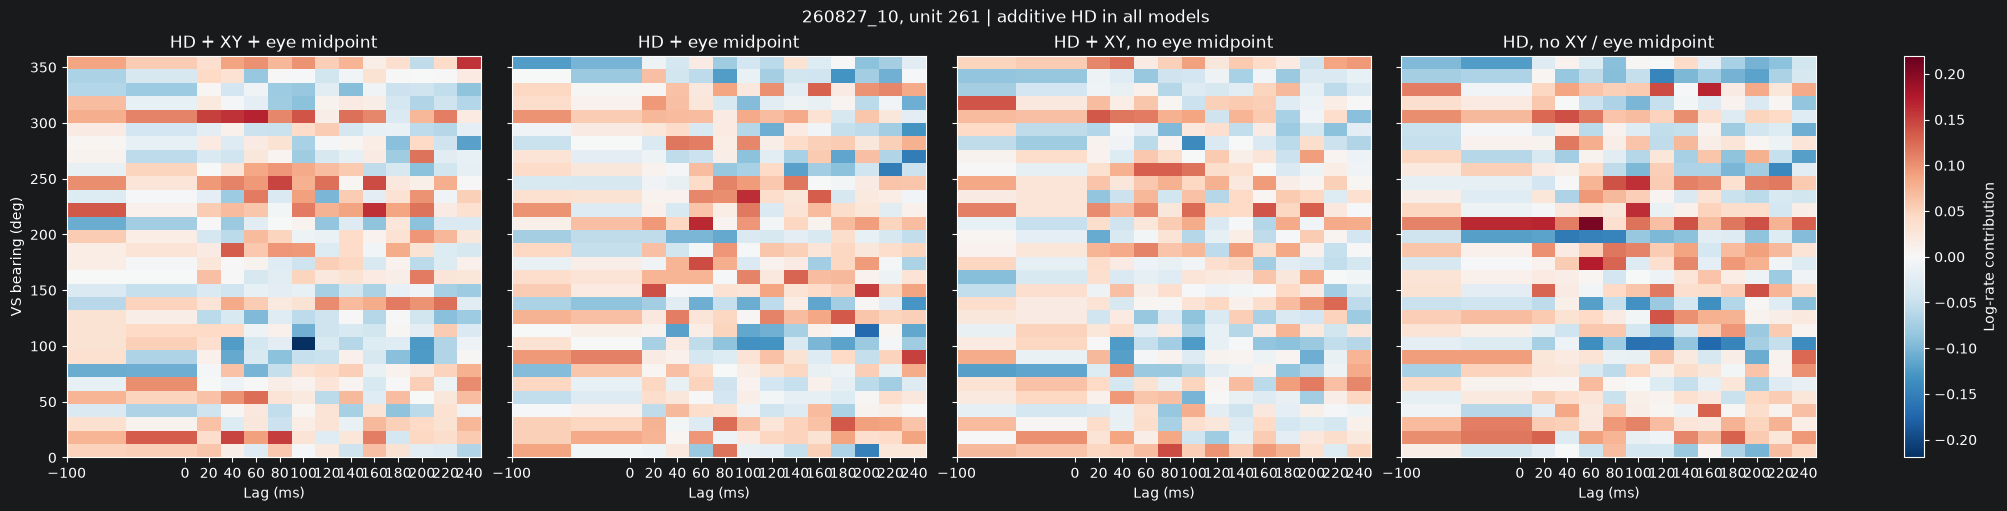

{'full_design_shape': [59977, 422],
 'eye_only_design_shape': [59977, 422],
 'xy_no_eye_design_shape': [59977, 422],
 'hd_only_design_shape': [59977, 422],
 'test_spike_count': 4824,
 'test_log_likelihood_full': -7339.164322073269,
 'test_log_likelihood_eye_only': -7329.431875809759,
 'test_log_likelihood_xy_no_eye': -7326.489035308739,
 'test_log_likelihood_hd_only': -7338.666408026969,
 'xy_gain_over_eye_only_bits_per_spike': -0.0029106450995201242,
 'eye_midpoint_gain_over_xy_only_bits_per_spike': -0.003790749037527568,
 'eye_midpoint_gain_over_hd_only_bits_per_spike': 0.0027617358695478673,
 'xy_gain_over_hd_only_bits_per_spike': 0.003641839807555311,
 'full_gain_over_hd_only_bits_per_spike': -0.00014890922997225697,
 'rf_correlation_full_vs_eye_only': 0.11289588677207847,
 'rf_correlation_full_vs_xy_no_eye': 0.6793376127279863,
 'rf_correlation_full_vs_hd_only': 0.1544076618606318}

In [245]:
test_log_likelihood_full = float(np.sum(
    spike_counts[test] * np.log(predicted_counts[test])
    - predicted_counts[test]
))
test_log_likelihood_eye_only = float(np.sum(
    spike_counts[test] * np.log(predicted_counts_eye_only[test])
    - predicted_counts_eye_only[test]
))
test_log_likelihood_xy_no_eye = float(np.sum(
    spike_counts[test] * np.log(predicted_counts_xy_no_eye[test])
    - predicted_counts_xy_no_eye[test]
))
test_log_likelihood_hd_only = float(np.sum(
    spike_counts[test] * np.log(predicted_counts_hd_only[test])
    - predicted_counts_hd_only[test]
))
test_spike_count = spike_counts[test].sum()
comparison = {
    "full_design_shape": list(design.shape),
    "eye_only_design_shape": list(design_eye_only.shape),
    "xy_no_eye_design_shape": list(design_xy_no_eye.shape),
    "hd_only_design_shape": list(design_hd_only.shape),
    "test_spike_count": int(test_spike_count),
    "test_log_likelihood_full": test_log_likelihood_full,
    "test_log_likelihood_eye_only": test_log_likelihood_eye_only,
    "test_log_likelihood_xy_no_eye": test_log_likelihood_xy_no_eye,
    "test_log_likelihood_hd_only": test_log_likelihood_hd_only,
    "xy_gain_over_eye_only_bits_per_spike": float(
        (test_log_likelihood_full - test_log_likelihood_eye_only)
        / (test_spike_count * np.log(2))
    ),
    "eye_midpoint_gain_over_xy_only_bits_per_spike": float(
        (test_log_likelihood_full - test_log_likelihood_xy_no_eye)
        / (test_spike_count * np.log(2))
    ),
    "eye_midpoint_gain_over_hd_only_bits_per_spike": float(
        (test_log_likelihood_eye_only - test_log_likelihood_hd_only)
        / (test_spike_count * np.log(2))
    ),
    "xy_gain_over_hd_only_bits_per_spike": float(
        (test_log_likelihood_xy_no_eye - test_log_likelihood_hd_only)
        / (test_spike_count * np.log(2))
    ),
    "full_gain_over_hd_only_bits_per_spike": float(
        (test_log_likelihood_full - test_log_likelihood_hd_only)
        / (test_spike_count * np.log(2))
    ),
    "rf_correlation_full_vs_eye_only": float(
        np.corrcoef(rf.ravel(), rf_eye_only.ravel())[0, 1]
    ),
    "rf_correlation_full_vs_xy_no_eye": float(
        np.corrcoef(rf.ravel(), rf_xy_no_eye.ravel())[0, 1]
    ),
    "rf_correlation_full_vs_hd_only": float(
        np.corrcoef(rf.ravel(), rf_hd_only.ravel())[0, 1]
    ),
}
(output_dir / f"{unit_id}_geometry_comparison.json").write_text(
    json.dumps(comparison, indent=2) + "\n"
)
np.savetxt(
    output_dir / f"{unit_id}_geometry_comparison.csv",
    np.column_stack([
        time, spike_counts, predicted_counts, predicted_counts_eye_only,
        predicted_counts_xy_no_eye, predicted_counts_hd_only, train, test,
    ]),
    delimiter=",", comments="", fmt="%.18g",
    header="time,spike_counts,predicted_full,predicted_eye_only,"
           "predicted_xy_no_eye,predicted_hd_only,train,test",
)

rf_panels = [rf, rf_eye_only, rf_xy_no_eye, rf_hd_only]
panel_titles = [
    "HD + XY + eye midpoint", "HD + eye midpoint",
    "HD + XY, no eye midpoint", "HD, no XY / eye midpoint",
]
limit = max(np.abs(panel).max() for panel in rf_panels)
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True, layout="constrained")
for axis, panel, title in zip(axes, rf_panels, panel_titles):
    plot = axis.pcolormesh(
        lags * 1000, angle_centers, panel, shading="nearest",
        cmap="RdBu_r", vmin=-limit, vmax=limit,
    )
    axis.set(
        xlabel="Lag (ms)",
        xlim=(pre_onset_lag * 1000, max_lag * 1000), ylim=(0, 360),
        xticks=lags * 1000, title=title,
    )
axes[0].set_ylabel("VS bearing (deg)")
fig.suptitle(f"{session_dir.name}, unit {unit_id} | additive HD in all models")
fig.colorbar(plot, ax=axes, label="Log-rate contribution")
fig.savefig(output_dir / f"{unit_id}_geometry_comparison.png", dpi=160)
plt.show()
comparison


## 13. Diagnose RF width：HD sign / onset vs dynamic / additive HD

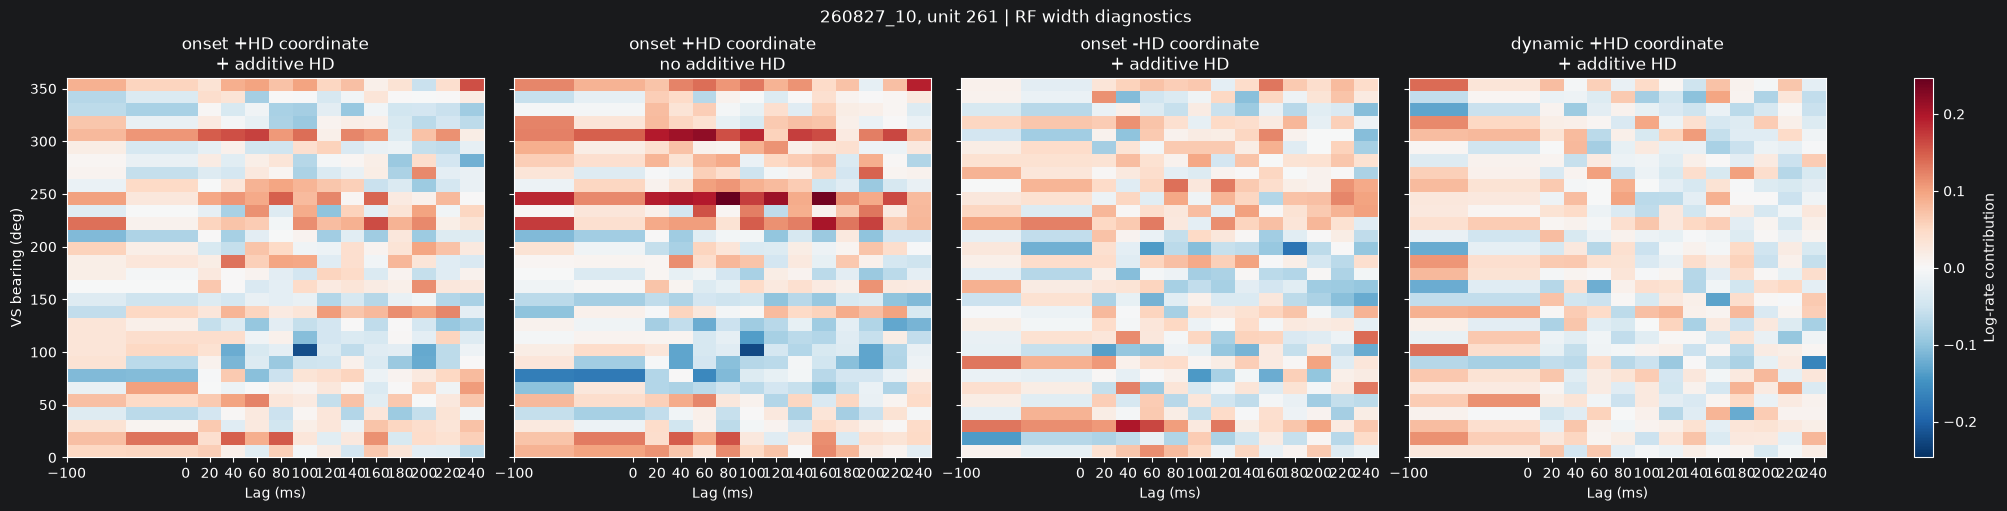

{'bin_size_seconds': 0.02,
 'angle_bin_size_degrees': 12,
 'pre_onset_lag_seconds': -0.1,
 'max_lag_seconds': 0.25,
 'vs_parameter_count': 420,
 'test_spike_count': 4824,
 'test_log_likelihoods': {'hd_only_no_vs': -7322.211192276722,
  'onset_plus_hd_coordinate_no_additive_hd': -9419.141611143947,
  'onset_minus_hd_coordinate_additive_hd': -7342.549960958502,
  'dynamic_plus_hd_coordinate_additive_hd': -7367.322547726173,
  'onset_plus_hd_coordinate_additive_hd': -7339.164322073269,
  'intercept_only': -9414.088980479164},
 'hd_over_intercept_bits_per_spike': np.float64(0.6256098074596678),
 'vs_only_over_intercept_bits_per_spike': np.float64(-0.0015110707304156921),
 'vs_gain_given_hd_bits_per_spike': np.float64(-0.005070107024259189),
 'additive_hd_gain_given_vs_bits_per_spike': np.float64(0.6220507711658242),
 'plus_hd_coordinate_over_minus_hd_coordinate_bits_per_spike': np.float64(0.0010125299398768967),
 'dynamic_over_onset_bits_per_spike': np.float64(-0.008421171747445373)}

In [246]:
diagnostic_designs = {
    "hd_only_no_vs": hd_features,
    "onset_plus_hd_coordinate_no_additive_hd": vs_design,
    "onset_minus_hd_coordinate_additive_hd": np.column_stack([
        vs_design_minus_hd, hd_features,
    ]),
    "dynamic_plus_hd_coordinate_additive_hd": np.column_stack([
        vs_design_dynamic, hd_features,
    ]),
}
diagnostic_models = {}
diagnostic_predictions = {}
for name, diagnostic_design in diagnostic_designs.items():
    diagnostic_model = nmo.glm.GLM(
        observation_model=nmo.observation_models.PoissonObservations(),
        regularizer="Ridge",
        regularizer_strength=regularizer_strength,
        solver_name="LBFGS",
        solver_kwargs={"maxiter": 2000},
    )
    diagnostic_model.fit(diagnostic_design[train], spike_counts[train])
    diagnostic_models[name] = diagnostic_model
    diagnostic_predictions[name] = np.asarray(
        diagnostic_model.predict(diagnostic_design)
    )

main_name = "onset_plus_hd_coordinate_additive_hd"
diagnostic_predictions[main_name] = predicted_counts
diagnostic_predictions["intercept_only"] = np.full(
    len(spike_counts), spike_counts[train].mean(),
)
test_log_likelihoods = {
    name: float(np.sum(
        spike_counts[test] * np.log(prediction[test]) - prediction[test]
    ))
    for name, prediction in diagnostic_predictions.items()
}
test_spike_count = int(spike_counts[test].sum())
bits_per_spike_denominator = test_spike_count * np.log(2)
signal_comparison = {
    "bin_size_seconds": bin_size,
    "angle_bin_size_degrees": angle_bin_size,
    "pre_onset_lag_seconds": pre_onset_lag,
    "max_lag_seconds": max_lag,
    "vs_parameter_count": vs_feature_count,
    "test_spike_count": test_spike_count,
    "test_log_likelihoods": test_log_likelihoods,
    "hd_over_intercept_bits_per_spike": (
        test_log_likelihoods["hd_only_no_vs"]
        - test_log_likelihoods["intercept_only"]
    ) / bits_per_spike_denominator,
    "vs_only_over_intercept_bits_per_spike": (
        test_log_likelihoods["onset_plus_hd_coordinate_no_additive_hd"]
        - test_log_likelihoods["intercept_only"]
    ) / bits_per_spike_denominator,
    "vs_gain_given_hd_bits_per_spike": (
        test_log_likelihoods[main_name]
        - test_log_likelihoods["hd_only_no_vs"]
    ) / bits_per_spike_denominator,
    "additive_hd_gain_given_vs_bits_per_spike": (
        test_log_likelihoods[main_name]
        - test_log_likelihoods["onset_plus_hd_coordinate_no_additive_hd"]
    ) / bits_per_spike_denominator,
    "plus_hd_coordinate_over_minus_hd_coordinate_bits_per_spike": (
        test_log_likelihoods[main_name]
        - test_log_likelihoods["onset_minus_hd_coordinate_additive_hd"]
    ) / bits_per_spike_denominator,
    "dynamic_over_onset_bits_per_spike": (
        test_log_likelihoods["dynamic_plus_hd_coordinate_additive_hd"]
        - test_log_likelihoods[main_name]
    ) / bits_per_spike_denominator,
}
(output_dir / f"{unit_id}_signal_diagnostics.json").write_text(
    json.dumps(signal_comparison, indent=2) + "\n"
)

def rf_from_model(fitted_model):
    coefficients = np.asarray(fitted_model.coef_)[:vs_feature_count].reshape(
        len(lags), angle_count,
    ).T
    return angle_basis @ coefficients @ lag_basis.T

diagnostic_rfs = {
    main_name: rf,
    "onset_plus_hd_coordinate_no_additive_hd": rf_from_model(
        diagnostic_models["onset_plus_hd_coordinate_no_additive_hd"]
    ),
    "onset_minus_hd_coordinate_additive_hd": rf_from_model(
        diagnostic_models["onset_minus_hd_coordinate_additive_hd"]
    ),
    "dynamic_plus_hd_coordinate_additive_hd": rf_from_model(
        diagnostic_models["dynamic_plus_hd_coordinate_additive_hd"]
    ),
}
np.savetxt(
    output_dir / f"{unit_id}_signal_diagnostic_rfs.csv",
    np.column_stack([
        np.repeat(angle_centers, len(lags)),
        np.tile(lags, angle_count),
        *[panel.ravel() for panel in diagnostic_rfs.values()],
    ]),
    delimiter=",", comments="", fmt="%.18g",
    header="vs_bearing,lag," + ",".join(diagnostic_rfs),
)

panel_titles = [
    "onset +HD coordinate\n+ additive HD",
    "onset +HD coordinate\nno additive HD",
    "onset -HD coordinate\n+ additive HD",
    "dynamic +HD coordinate\n+ additive HD",
]
limit = max(np.abs(panel).max() for panel in diagnostic_rfs.values())
fig, axes = plt.subplots(
    1, 4, figsize=(20, 5), sharex=True, sharey=True, layout="constrained",
)
for axis, panel, title in zip(axes, diagnostic_rfs.values(), panel_titles):
    plot = axis.pcolormesh(
        lags * 1000, angle_centers, panel, shading="nearest",
        cmap="RdBu_r", vmin=-limit, vmax=limit,
    )
    axis.set(
        xlabel="Lag (ms)",
        xlim=(pre_onset_lag * 1000, max_lag * 1000), ylim=(0, 360),
        xticks=lags * 1000, title=title,
    )
axes[0].set_ylabel("VS bearing (deg)")
fig.suptitle(f"{session_dir.name}, unit {unit_id} | RF width diagnostics")
fig.colorbar(plot, ax=axes, label="Log-rate contribution")
fig.savefig(output_dir / f"{unit_id}_signal_diagnostics.png", dpi=160)
plt.show()
signal_comparison


In [247]:
coef_full = np.asarray(model.coef_)
coef_eye_only = np.asarray(model_eye_only.coef_)
coef_xy_no_eye = np.asarray(model_xy_no_eye.coef_)
coef_hd_only = np.asarray(model_hd_only.coef_)

print(coef_full)
print("---------- below is HD + eye midpoint ----------")
print(coef_eye_only)
print("---------- below is HD + XY, no eye midpoint ----------")
print(coef_xy_no_eye)
print("---------- below is HD, no XY / eye midpoint ----------")
print(coef_hd_only)

[ 5.02213277e-02  7.46269077e-02  3.48930806e-02 -3.15258875e-02
  7.51609802e-02 -1.81814469e-02 -1.08105153e-01  3.53381634e-02
  3.09088714e-02  3.21437381e-02  3.11827064e-02 -6.14480153e-02
 -3.26300785e-02 -4.57391754e-04  1.62654798e-02  1.63641479e-02
  5.63594587e-02 -1.09292626e-01  1.35883033e-01 -2.98173130e-02
  1.01638928e-01 -1.55569725e-02  8.56411364e-03  4.11685277e-03
  1.80194583e-02  8.04612115e-02  6.84475079e-02 -6.42185584e-02
 -7.02942833e-02  8.70253146e-02  5.24525382e-02  1.33275703e-01
  7.28880754e-03 -6.71529248e-02  4.91314754e-02  1.02130421e-01
 -1.06475793e-01 -6.71704188e-02  5.18979318e-02  4.34127487e-02
  1.44577380e-02  5.04085682e-02 -5.07162958e-02 -8.10769503e-04
 -3.87296872e-03  2.92631332e-02  1.55726476e-02 -7.56699443e-02
  1.11043314e-02 -1.74242922e-03  2.82967612e-02  4.93192673e-02
 -5.79438731e-02 -1.73522234e-02 -4.08945531e-02  1.09143130e-01
 -1.86518990e-02 -8.03634077e-02 -3.62864062e-02  5.52630611e-02
  6.10381886e-02  4.07974